## Imports

In [1]:
# importing sys
import sys
# This is how you import modules that exist outside of working directory 
# adding mosaique to the system path
sys.path.insert(1, '/workspaces/QML-QPF/mosaiQue') 
sys.path.insert(1, '/workspaces/QML-QPF/Quantifying_Entanglement')

import mosaique as mq
import scipy
from concurrent.futures import ProcessPoolExecutor, as_completed
import itertools
import numpy as np
import pennylane as qml
import os
from mosaique.models.operation import OperationLayer
from tensorflow import keras
import tensorflow as tf 
import time
from Entropy import compute_entropy_for_pair_batch

2026-02-08 09:37:04.466953: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-08 09:37:04.522915: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Check GPU installation is working

In [3]:
import tensorrt as trt

print(f' tensorflow version {tf.__version__}')

print(f' tensorrt version {trt.__version__}')

print(tf.config.list_physical_devices('GPU'))

 tensorflow version 2.15.0
 tensorrt version 10.12.0.36
[]


In [ ]:

# Set the environment for asynchronous GPU usage
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

In [2]:
def operation():
    dev = qml.device("default.qubit.tf", wires=4)
    @qml.qnode(dev, interface='tf')
    def cnot(inputs):
        inputs = inputs * np.pi
        qml.AngleEmbedding(inputs[:,...], wires=range(4), rotation='Y')

        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[2, 3])

        # Measurement producing 4 classical output values
        return [qml.expval(qml.PauliZ(j)) for j in range(4)]
    return cnot


In [3]:
def preset():
    # load the data
    mnist_dataset = keras.datasets.mnist
    
    # name of the folder where will save the filtered images for training
    tr_layer = mq.ConvolutionLayer4x4("_OA_results_Mnist_train_with_val")
    # name of the folder where will save the filtered images for testing
    te_layer = mq.ConvolutionLayer4x4("_OA_results_Mnist_test_with_val")
    
    
    (tr_images, tr_labels), (te_images, te_labels) = mnist_dataset.load_data()
    
   
    tr_layer.fit(tr_images)
    te_layer.fit(te_images)
    tr_images = tr_layer.transform(tr_images)
    te_images = te_layer.transform(te_images)
    return ((tr_layer, (tr_images, tr_labels)), (te_layer,(te_images, te_labels)))

with ProcessPoolExecutor() as executor:
    future = executor.submit(preset)

((train_layer, (train_images, train_labels)), (test_layer,(test_images, test_labels))) = future.result() #This blocks until the task completes

In [4]:

permutations = np.asarray(list(itertools.permutations(range(4))))

def pool(x, call, p, l):
    op = OperationLayer(call())
    predict = l.post_transform(op.pre_op.predict(x,batch_size=1000))
    l.save(predict, p)

In [ ]:
for j in range(3):
    with ProcessPoolExecutor(8) as executor:
        runner = {
            executor.submit(pool, x=train_images[:,:,p], call=operation, p=p, l=train_layer): p for p in permutations[8*j:8*(j+1)]
        }
        for future in as_completed(runner):
            runner.pop(future)

In [ ]:
for j in range(3):
    with ProcessPoolExecutor(8) as executor:
        runner = {
            executor.submit(pool, x=test_images[:,:,p], call=operation, p=p, l=test_layer): p for p in permutations[8*j:8*(j+1)]
        }
        for future in as_completed(runner):
            runner.pop(future)

## Filtering Data by Entropy degree

In [ ]:
train_images.shape

In [ ]:
permutations[12]

In [ ]:
train_layer.name

In [ ]:
input_system_03 = np.array([[2,3],[1,5],[8,3],[1,9],]) 
input_system_21 = np.array([[20,30],[7,58],[24,34],[15,54],])
# Assuming the same slicing  input_system_03 = input_data[:, :, :2]

task_inputs = list(zip(input_system_03, input_system_21))
task_inputs

In [ ]:
input1_batch, input2_batch = task_inputs

In [ ]:
print(input1_batch, input2_batch)

In [6]:
# --- Function to process a single input type ---
def process_input_type(input_data, config, entropy_dict_for_symm):
    """
    Helper function to encapsulate the parallel processing logic for one input type.
    """
    input_system_03 = input_data[:, :, :2]
    input_system_21 = input_data[:, :, 2:4] # Assuming the same slicing  input_system_03 = input_data[:, :, :2]

    task_inputs = list(zip(input_system_03, input_system_21))
    # print("Im inside process_input_type")
    # print("len of task inputs is ", len(task_inputs) )
    # print(f"\nStarting parallel entropy computation for {data_name} data ({len(task_inputs)} batches)...")
    type_start_time = time.time()
    # from collections import defaultdict

    # entropy_dict_for_symm = defaultdict(list)   # missing keys become []
    # config = ''.join(map(str, config)) 
    with ProcessPoolExecutor(max_workers=None) as executor:
        results_iterator = executor.map(compute_entropy_for_pair_batch, task_inputs)

        for i, result in enumerate(results_iterator):
            # print(f"i is {i} and result is {type(result)} len {len(result)}")
            (avg_s1_rho0, avg_s1_rho1), \
            (avg_s2_rho0, avg_s2_rho1), \
            (max_s1_rho0, max_s1_rho1), \
            (max_s2_rho0, max_s2_rho1), \
            (S1_rho_0), \
            (S1_rho_1), \
            (S2_rho_0), \
            (S2_rho_1) = result
            
            # Append to the lists directly from the dictionary
            # Using dictionary keys here
            entropy_dict_for_symm['Total_Avg_' + config + '_Entropy_S1'].append((avg_s1_rho0, avg_s1_rho1))
            entropy_dict_for_symm['Total_Avg_' + config + '_Entropy_S2'].append((avg_s2_rho0, avg_s2_rho1))
            entropy_dict_for_symm['Total_Max_' + config + '_Entropy_S1'].append((max_s1_rho0, max_s1_rho1))
            entropy_dict_for_symm['Total_Max_' + config + '_Entropy_S2'].append((max_s2_rho0, max_s2_rho1))
            # New ones to capture pair entanglement for subsequent filtering
            entropy_dict_for_symm['S1_rho_0_' + config + '_Entropy_S1_0'].append(S1_rho_0)
            entropy_dict_for_symm['S1_rho_1_' + config + '_Entropy_S1_1'].append(S1_rho_1)
            entropy_dict_for_symm['S2_rho_0_' + config + '_Entropy_S2_0'].append(S2_rho_0)
            entropy_dict_for_symm['S2_rho_1_' + config + '_Entropy_S2_1'].append(S2_rho_1)

            if (i + 1) % 100 == 0:
                print(f"Processed {i + 1}/{len(task_inputs)} batches for {config}.")
                
        
        # Convert lists to NumPy arrays
        entropy_dict_for_symm['Total_Avg_' + config + '_Entropy_S1'] = np.array(entropy_dict_for_symm['Total_Avg_' + config + '_Entropy_S1'])
        entropy_dict_for_symm['Total_Avg_' + config + '_Entropy_S2'] = np.array(entropy_dict_for_symm['Total_Avg_' + config + '_Entropy_S2'])
        entropy_dict_for_symm['Total_Max_' + config + '_Entropy_S1'] = np.array(entropy_dict_for_symm['Total_Max_' + config + '_Entropy_S1'])
        entropy_dict_for_symm['Total_Max_' + config + '_Entropy_S2'] = np.array(entropy_dict_for_symm['Total_Max_' + config + '_Entropy_S2'])
        # New ones to capture pair entanglement for subsequent filtering
        entropy_dict_for_symm['S1_rho_0_' + config + '_Entropy_S1_0']  = np.array(entropy_dict_for_symm['S1_rho_0_' + config + '_Entropy_S1_0'])    
        entropy_dict_for_symm['S1_rho_1_' + config + '_Entropy_S1_1']  = np.array(entropy_dict_for_symm['S1_rho_1_' + config + '_Entropy_S1_1'])
        entropy_dict_for_symm['S2_rho_0_' + config + '_Entropy_S2_0']  = np.array(entropy_dict_for_symm['S2_rho_0_' + config + '_Entropy_S2_0'])
        entropy_dict_for_symm['S2_rho_1_' + config + '_Entropy_S2_1']  = np.array(entropy_dict_for_symm['S2_rho_1_' + config + '_Entropy_S2_1'])
        
        # compute the total entry of the entire system S1 + S2
        # Compute the total entropy of the entire system S1 + S2
        # Ensure avg_s1_array and avg_s2_array are in the correct shape (N, 2)
        # The output of compute_entropy_for_pair_batch is (rho0, rho1) tuples, which will become (N, 2) arrays.
        entropy_dict_for_symm['Total_Avg_' + config + '_Entropy_S1_S2'] = entropy_dict_for_symm['Total_Avg_' + config + '_Entropy_S1'] \
                                                                            + entropy_dict_for_symm['Total_Avg_' + config + '_Entropy_S2']
        entropy_dict_for_symm[f'Total_Max_{config}_Entropy_S1_S2'] = entropy_dict_for_symm['Total_Max_' + config + '_Entropy_S1'] \
                                                                            + entropy_dict_for_symm['Total_Max_' + config + '_Entropy_S2']

    # --- Saving Data as CSV ---
    # 1. Create the data_name specific folder

    entropy_folder_name = train_layer.name + f"/{config}/Entropy"
    # train
    # entropy_folder_name = "_OA_train"
    output_folder_path = os.path.join(entropy_folder_name) # Replace spaces for folder names
    os.makedirs(output_folder_path, exist_ok=True)
    print(f"Created/Ensured directory: {output_folder_path}")

    # 2. Save each list/array corresponding to each key as a CSV file
    for key, value in entropy_dict_for_symm.items():
        if isinstance(value, np.ndarray): # Only save if it's a NumPy array
            file_path = os.path.join(output_folder_path, f"{key}.csv")
            # Use fmt='%.8f' for float formatting, delimiter=',' for CSV
            np.savetxt(file_path, value, delimiter=',', fmt='%.8f')
            print(f"Saved {key}.csv to {output_folder_path}")
        else:
            print(f"Skipping saving for key '{key}' as it's not a NumPy array (type: {type(value)})")
    type_end_time = time.time()
    print(f"Finished parallel computation for data for config {config} in {type_end_time - type_start_time:.2f} seconds.")

In [ ]:
input_system_03 = input_data[:, :, :2]
input_system_21 = input_data[:, :, 2:4] # Assuming the same slicing for all input types

task_inputs = list(zip(input_system_03, input_system_21))


In [ ]:
# Scaling data
scaled_sample = train_images
# Encoding data using angle encoding
input = scaled_sample * np.pi

In [ ]:
input.shape

In [ ]:
input[0,0]

In [ ]:
input_data = input
input_system_03 = input_data[:, :, :2]
input_system_21 = input_data[:, :, 2:4] 
task_inputs = list(zip(input_system_03, input_system_21))

In [ ]:
task_inputs[1][1].shape

In [ ]:
input1_batch, input2_batch = task_inputs

In [ ]:
len(task_inputs)

In [ ]:
train_images[0]

In [5]:
D = {"Configs": { 
                  "P_diagonal_config" : np.asarray([0,3,2,1]),
                  "P_vertical_config" : np.asarray([1,0,3,2]),
                  "P_horizontal_config" : np.asarray([1,3,2,0])
                }
    }
D_configs = D["Configs"].values()
for co in D_configs: print(co)

[0 3 2 1]
[1 0 3 2]
[1 3 2 0]


In [37]:
# Scaling data
scaled_sample = train_images/255.
# Encoding data using angle encoding
scaled_sample = scaled_sample * np.pi
from collections import defaultdict


for config in D_configs:
    # rearranging the input in respect to the configs
    input = scaled_sample[:,:,config]

    entropy_dict_for_symm = defaultdict(list)   # missing keys become []
    config = ''.join(map(str, config))
    process_input_type(input, config, entropy_dict_for_symm)
    # break

Processed 100/60000 batches for 0321.
Processed 200/60000 batches for 0321.
Processed 300/60000 batches for 0321.
Processed 400/60000 batches for 0321.
Processed 500/60000 batches for 0321.
Processed 600/60000 batches for 0321.
Processed 700/60000 batches for 0321.
Processed 800/60000 batches for 0321.
Processed 900/60000 batches for 0321.
Processed 1000/60000 batches for 0321.
Processed 1100/60000 batches for 0321.
Processed 1200/60000 batches for 0321.
Processed 1300/60000 batches for 0321.
Processed 1400/60000 batches for 0321.
Processed 1500/60000 batches for 0321.
Processed 1600/60000 batches for 0321.
Processed 1700/60000 batches for 0321.
Processed 1800/60000 batches for 0321.
Processed 1900/60000 batches for 0321.
Processed 2000/60000 batches for 0321.
Processed 2100/60000 batches for 0321.
Processed 2200/60000 batches for 0321.
Processed 2300/60000 batches for 0321.
Processed 2400/60000 batches for 0321.
Processed 2500/60000 batches for 0321.
Processed 2600/60000 batches for 0

In [ ]:
permutations[-3:]

In [ ]:
# Scaling data
scaled_sample = train_images/255.
# Encoding data using angle encoding
input = scaled_sample * np.pi
from collections import defaultdict

for config in permutations[-3:]:
    # rearranging the input in respect to the configs
    input = scaled_sample[:,:,config]

    entropy_dict_for_symm = defaultdict(list)   # missing keys become []
    config = ''.join(map(str, config))
    process_input_type(input, config, entropy_dict_for_symm)
    # break

In [ ]:
# --- Function to process and print statistics from a CSV file ---
def analyze_entropy_file(file_path):
    try:
        # Load the data from the CSV file
        data = np.loadtxt(file_path, delimiter=',')

        # Handle cases where data might be a single value or 1D array
        if data.ndim == 0: # A single number
            data = np.array([data])
        elif data.ndim == 1: # A single column or row
            # If it's (N,), mean/var will be single values.
            # If it's (N, 2), it will remain (N, 2).
            pass # np.mean and np.var handle 1D arrays correctly for axis=0

        # Compute average (mean) along axis=0 (for each column)
        avg_values = np.mean(data, axis=0)
        # Compute variance along axis=0 (for each column)
        var_values = np.var(data, axis=0)
        # Compute Standard Deviation along axis=0 (for each column)
        std_values = np.std(data, axis=0)
        

        # print(f"\n--- Analysis for: {data_name} / {symmetry_name} / {entropy_key} ---")
        print(f"File: {file_path}")
        print(f"Data Shape: {data.shape}")
        print(f"Average (Mean) per column: {avg_values}")
        # print(f"Variance per column: {var_values}")
        # print(f"Standard Deviation per column: {std_values}")
        return avg_values

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

In [ ]:
for config in permutations:
    # rearranging the input in respect to the configs
    input = input[:,:,config]
    config = ''.join(map(str, config))
    entropy_folder_name = train_layer.name + f"/{config}/Entropy/Total_Avg_{config}_Entropy_S1_S2.csv"
    avg_entropy = analyze_entropy_file(entropy_folder_name)
    
    

In [ ]:
train_layer.open(permutations[0]).shape

In [7]:
import numpy as np

file_path = "/workspaces/QML-QPF/Entanglement_Filtering/_OA_results_Mnist_train_with_val/0123/Entropy/S1_rho_0_0123_Entropy_S1.csv"
data = np.loadtxt(file_path, delimiter=',')

In [23]:
data.shape

(60000, 196)

In [33]:
file_path = "/workspaces/QML-QPF/Entanglement_Filtering/_OA_results_Mnist_train_with_val/0321/Entropy/S1_rho_1_0321_Entropy_S1_1.csv"
data1 = np.loadtxt(file_path, delimiter=',')
file_path = "/workspaces/QML-QPF/Entanglement_Filtering/_OA_results_Mnist_train_with_val/0321/Entropy/S2_rho_1_0321_Entropy_S2_1.csv"
data2 = np.loadtxt(file_path, delimiter=',')
np.average(np.average(data1+data2, axis=1))

0.1026195748132466

In [20]:
file_path = "/workspaces/QML-QPF/Entanglement_Filtering/_OA_results_Mnist_train_with_val/0321/Entropy/Total_Avg_0321_Entropy_S1_S2.csv"
data = np.loadtxt(file_path, delimiter=',')
np.average(data)

0.10261957492966667

In [10]:
file_path = "/workspaces/QML-QPF/Entanglement_Filtering/_OA_results_Mnist_train_with_val/0321/Entropy/Total_Avg_0321_Entropy_S1.csv"
data = np.loadtxt(file_path, delimiter=',')
np.mean(data, axis=0)

array([0.04902366, 0.04902366])

In [9]:
np.mean(np.mean(data, axis=0), axis=0)

0.047750174088953636

In [ ]:

# Check if any element is greater than 2
# condition_array = a > 2 
# condition_array is now a boolean array: [False, False, False, True, True]

# result = condition_array.any() 
for i in range(len(input[0])):
    for el in input[0][i]:
        if el - 0 > 0.0001:
            print(i)


In [ ]:
input[0][34]

In [ ]:
i = 20
s = 20
data[1][i:i+s]

In [ ]:
data[0][34]

In [56]:
Diagonal = np.asarray([0,3,2,1])
# filtered_input = train_layer.open(Diagonal)
# reshaped_filtered_input = train_layer.transform(filtered_input)


In [174]:
for _, value in D.items():
    for _, symmetry in value.items():
        print(symmetry, _[2:-7])

[0 3 2 1] diagonal
[1 0 3 2] vertical
[1 3 2 0] horizontal


In [ ]:
filtered_input.shape

In [ ]:
reshaped_filtered_input = train_layer.transform(filtered_input)

In [ ]:
reshaped_filtered_input[0]

In [ ]:
reshaped_filtered_input[0,2,:] == filtered_input[0,0,2,:]

In [177]:
#S1_rho_0_0321_Entropy_S1 : S1_rho_0 = system 1;Entropy_S1 = qubit 1

file_path = "/workspaces/QML-QPF/Entanglement_Filtering/_OA_results_Mnist_train_with_val/0321/Entropy/S1_rho_0_0321_Entropy_S1.csv"
S1_rho0 = np.loadtxt(file_path, delimiter=',')
file_path = "/workspaces/QML-QPF/Entanglement_Filtering/_OA_results_Mnist_train_with_val/0321/Entropy/S2_rho_0_0321_Entropy_S1.csv"
S2_rho0 = np.loadtxt(file_path, delimiter=',')
# File namne to store the pooled sample
Entanglement_pooled_file_name = f"{train_layer.name}/{''.join(map(str,Diagonal))}/Entanglement_pooled_Dgl_{''.join(map(str,Diagonal))}"  


In [203]:
S1_rho0.shape
m_all = np.array([S1_rho0,S2_rho0]) + np.array([S1_rho0,S2_rho0])

print(m_all.mean())

0.09809396026946848


In [205]:
(m_all + m_all).mean()

0.19618792053893697

In [199]:
(S1_rho0.mean(axis=1)).shape

(60000,)

In [193]:
S1_rho0.shape

(60000, 196)

In [192]:
file_path = "/workspaces/QML-QPF/Quantifying_Entanglement/_OA_train/Mnist/Diagonal/Total_Avg_Diagonal_Entropy_S1.csv"
SAvg  = np.loadtxt(file_path, delimiter=',')
SAvg.shape

(60000, 2)

In [186]:
file_path = "/workspaces/QML-QPF/Entanglement_Filtering/_OA_results_Mnist_train_with_val/0321/Entropy/Total_Avg_0321_Entropy_S1_S2.csv"
SAvg  = np.loadtxt(file_path, delimiter=',')
SAvg.mean(axis=1)


array([0.09768781, 0.13766344, 0.04930123, ..., 0.11880489, 0.11734725,
       0.14971091])

In [6]:
Entanglement_pooled_file_name = f"{train_layer.name}/{''.join(map(str,Diagonal))}/Entanglement_pooled_Dgl_{''.join(map(str,Diagonal))}"  
Entanglement_pooled_file_name

'_OA_results_Mnist_train_with_val/0321/Entanglement_pooled_Dgl_0321'

In [ ]:
S2_rho0.shape

In [ ]:
a = np.array([],)

In [ ]:
np.append(a, [1,3])

In [ ]:
l = []

In [ ]:
type(l)

In [ ]:
l.extend([1,3])

In [ ]:
l

### How to flatten a list of lists of different length


We will focus only in the best 3 configs.

In [8]:
D = {"Configs": { 
                  "P_diagonal_config" : np.asarray([0,3,2,1]),
                  "P_vertical_config" : np.asarray([1,0,3,2]),
                  "P_horizontal_config" : np.asarray([1,3,2,0])
                }
    }

In [9]:
def open_load_entropy(symmetry, system, dataset_name="Mnist"):
    
    system = str(system)
    file_path = f"/workspaces/QML-QPF/Entanglement_Filtering/{dataset_name}/_OA_results_{dataset_name}_train_with_val/{symmetry}/Entropy/S{system}_rho_0_{symmetry}_Entropy_S{system}_0.csv"
    S_rho0 = np.loadtxt(file_path, delimiter=',')
    return S_rho0
    

## Entanglement pooling and saving 

In [ ]:
import joblib
import gc

def Entanglement_pooling(input, sample_size, threshold, S1_rho0, S2_rho0,Entanglement_pooled_file_name):
    """
    Function that will filter the output of the quantum circuit based on a threshold e.g. the mean of the entier dataset
    
    """
    # sample_size = reshaped_filtered_input.shape[0]  # number of images
    Entanglement_pooled_sample = list()
    # threshold = 0.106 # The mean of the entire dataset--will update it accordingly
    for i in range(sample_size):
        Entanglement_pooled_img = list()
        for j in range(S1_rho0.shape[-1]):
            #
            tmp_list = list()
            # Checking for S1
            if S1_rho0[i,j] < threshold: # keeping both qubits
                tmp_list.extend(input[i,j,:2]) 
            else: # Keeping only target qubit
                tmp_list.append(input[i,j,1])
                
            # Checking for S2
            if S2_rho0[i,j] < threshold: # keeping both qubits
                tmp_list.extend(input[i,j,2:]) 
            else: # Keeping only target qubit
                tmp_list.append(input[i,j,-1])
            # appending the pooled filtered input to the image
            Entanglement_pooled_img.append(tmp_list)
        # appending the pooled filtered image to the sample
        Entanglement_pooled_sample.append(Entanglement_pooled_img)
        
    joblib.dump(Entanglement_pooled_sample, f'{Entanglement_pooled_file_name}.joblib', compress=3)

    # free memory so the notebook stays fast
    del Entanglement_pooled_sample
    gc.collect()
        

In [10]:
import numpy as np

def Entntanglement_pool(input_data, symmetry, Entanglement_pooled_file_name):
    X = input_data.astype(np.float32, copy=False)   # (N,196,4)
    #S1_rho_0_0321_Entropy_S1 : S1_rho_0 = system 1;Entropy_S1 = qubit 1
    S1_rho0 = open_load_entropy(symmetry, 1)
    S2_rho0 = open_load_entropy(symmetry, 2)
    thr1 = S1_rho0.mean(axis=1, keepdims=True)  # (N,1)
    thr2 = S2_rho0.mean(axis=1, keepdims=True)  # (N,1)

    m1 = (S1_rho0 < thr1)  # (N,196)
    m2 = (S2_rho0 < thr2)  # (N,196)

    pooled = np.empty_like(X, dtype=np.float32)
    pooled[..., 0] = X[..., 0] * m1
    pooled[..., 1] = X[..., 1]
    pooled[..., 2] = X[..., 2] * m2
    pooled[..., 3] = X[..., 3]

    np.save(f"{Entanglement_pooled_file_name}.npy", pooled)
    # np.save(f"{Entanglement_pooled_file_name}_thr1.npy", thr1.squeeze().astype(np.float32))  # optional
    # np.save(f"{Entanglement_pooled_file_name}_thr2.npy", thr2.squeeze().astype(np.float32))  # optional


### Entanglement pooling the best 3 symmetries from previous experiment 

In [11]:
for _, value in D.items():
    for _, config in value.items():
        # print(symmetry)
        # filtered_input = train_layer.open(config)
        # reshaped_filtered_input = train_layer.transform(filtered_input)
        
        # input with specific symmetry/config to filter based on entropy level
        filtered_input = train_layer.open(config)
        filtered_input = train_layer.transform(filtered_input)
        
        symmetry = ''.join(map(str,config))
        
        # file with _ctr0 : replacing ctr with 0 when Entropy/Entanglement greater than threshold 
        # File namne to store the pooled sample
        Entanglement_pooled_file_name = f"{train_layer.name}/{symmetry}/Entanglement_pooled_{_[2:-7]}_{''.join(map(str,symmetry))}_ctr0"  
        
        # print(Entanglement_pooled_file_name)
        
        Entntanglement_pool(input_data=filtered_input,
                            symmetry=symmetry,\
                            Entanglement_pooled_file_name=Entanglement_pooled_file_name)
        # # Entanglement filtering
        # Entanglement_pooling(input=filtered_input, symmetry=symmetry,\
        #                     sample_size=filtered_input.shape[0],\
        #                     Entanglement_pooled_file_name=Entanglement_pooled_file_name)


In [ ]:

def Entanglement_pooling( sample_size, threshold, S1_rho0, S2_rho0):
    """
    Function that will filter the output of the quantum circuit based on a threshold e.g. the mean of the entier dataset
    
    """
    sample_size = reshaped_filtered_input.shape[0]  # number of images
    Entanglement_pooled_sample = list()
    threshold = 0.106 # The mean of the entire dataset--will update it accordingly
    for i in range(sample_size):
        Entanglement_pooled_img = list()
        for j in range(S1_rho0.shape[-1]):
            #
            tmp_list = list()
            # Checking for S1
            if S1_rho0[i,j] < threshold: # keeping both qubits
                tmp_list.extend(reshaped_filtered_input[i,j,:2]) 
            else: # Keeping only target qubit
                tmp_list.append(reshaped_filtered_input[i,j,1])
                
            # Checking for S2
            if S2_rho0[i,j] < threshold: # keeping both qubits
                tmp_list.extend(reshaped_filtered_input[i,j,2:]) 
            else: # Keeping only target qubit
                tmp_list.append(reshaped_filtered_input[i,j,-1])
            # appending the pooled filtered input to the image
            Entanglement_pooled_img.append(tmp_list)
        # appending the pooled filtered image to the sample
        Entanglement_pooled_sample.append(Entanglement_pooled_img)
        
    joblib.dump(Entanglement_pooled_sample, f'{Entanglement_pooled_file_name}.joblib', compress=3)

    # free memory so the notebook stays fast
    del Entanglement_pooled_sample
    gc.collect()
        

0

In [ ]:
l=32
reshaped_filtered_input[0,l]

In [ ]:
reshaped_filtered_input

In [ ]:
len(Entanglement_pooled_sample[0])

In [ ]:
from matplotlib import pyplot as plt
post = filtered_input
_min, _max = np.amin(post), np.amax(post)
# _min1, _max1 = np.amin(post1), np.amax(post1)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Plot all output channels for quantum cnot
for c in range(4):
    axes[c].imshow(post[0,:,:,c],vmin = _min, vmax = _max)

### Row-Level Padding

In [ ]:
import numpy as np

def pad_jagged_image(image_list, max_c=4):
    # Create a fixed-size buffer of zeros
    padded_img = np.zeros((len(image_list), max_c))
    
    for i, row in enumerate(image_list):
        # row is a 1D array of length 2, 3, or 4
        length = len(row)
        padded_img[i, :length] = row
        
    return padded_img


In [ ]:
padded_S = [0]*4

In [ ]:
padded_S

In [ ]:
r = [1,2]
length = len(r)
padded_S[:length] = r
print(padded_S)

In [ ]:
len(Entanglement_pooled_sample[0])

In [ ]:
padded_Entanglement_pooled_sample = pad_jagged_image(Entanglement_pooled_sample[0])

In [ ]:
Entanglement_pooled_sample[0]

In [ ]:
padded_Entanglement_pooled_sample

### Reading the Entanglement pooled data

In [52]:
# Too long to load: almost 5mins => think of other way probably to save and laod
Entanglement_pooled_sample = joblib.load(f'{Entanglement_pooled_file_name}.joblib')

In [12]:
type(Entanglement_pooled_sample)

list

In [162]:
run_subfolders = [f"_{str(i+1)}FC" for i in range(4)]
run_subfolders

['_1FC', '_2FC', '_3FC', '_4FC']

## Approach 1: Padding with 0s

In [23]:
Ent_pooled_data_padded_0s = [pad_jagged_image(image) for image in Entanglement_pooled_sample]

In [25]:
Ent_pooled_data_padded_0s_array = np.array(Ent_pooled_data_padded_0s)

In [ ]:
Ent_pooled_data_padded_0s_array[0]

In [59]:
Entanglement_pooled_file_name_padded_0s = f"{train_layer.name}/{''.join(map(str,Diagonal))}/Entanglement_pooled_Dgl_{''.join(map(str,Diagonal))}"  
Entanglement_pooled_file_name_padded_0s


'_OA_results_Mnist_train_with_val/0321/Entanglement_pooled_Dgl_0321'

In [26]:
Ent_pooled_data_padded_0s_array.shape

(60000, 196, 4)

## Approach 2: Summing all 4 channels 

In [31]:
Ent_pooled_data_summed_array = np.array([[sum(p)/len(p) for p in img] for img in Entanglement_pooled_sample])

In [33]:
Ent_pooled_data_summed_array.shape

(60000, 196)

## Approach 3: Summing all 4 channels--Non filtered  
Original 4 channels output but summed and normalised 

In [151]:
filtered_input = train_layer.open(Diagonal)
filtered_input_summed_avg = filtered_input.mean(axis=-1)    # shape: (N, H, W)
filtered_input_summed_avg.shape


(60000, 14, 14)

In [ ]:
filtered_input_summed_avg[0]

## Trainign model


In [39]:
run_subfolder = "_1FC"
patience = 15
label = ''.join(map(str,Diagonal))

Entanglement_pool_folder_name = "Entanglement_pool_padded_0s"
# run_subfolder += f"/{Entanglement_pool_folder_name}/"


log_dir = train_layer.name + f"/{label}" + f"/{Entanglement_pool_folder_name}/run{run_subfolder}/"   



log_file =  log_dir + f"{Entanglement_pool_folder_name}_{label}"
log_file

'_OA_results_Mnist_train_with_val/0321/Entanglement_pool_padded_0s/run_1FC/Entanglement_pool_padded_0s_0321'

In [58]:
Entanglement_pool_folder_name = "No_Entanglement_pool_summed_avg"
label = ''.join(map(str,Diagonal))
run_subfolder = "_1FC"
log_dir = train_layer.name + f"/{label}" + f"/{Entanglement_pool_folder_name}/run{run_subfolder}/"   
    # print(' log_dir ', log_dir)
    
log_file =  log_dir + f"{Entanglement_pool_folder_name}_{label}"
log_file

'_OA_results_Mnist_train_with_val/0321/No_Entanglement_pool_summed_avg/run_1FC/No_Entanglement_pool_summed_avg_0321'

In [12]:
from keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau



def run(tr_images, label,  run_subfolder, folder_name, patience=15):
    log_dir = train_layer.name + f"/{label}" + f"/{folder_name}/run{run_subfolder}/"   
    # print(' log_dir ', log_dir)
    
    log_file =  log_dir + f"{folder_name}_{label}"
    # print(' log_file ', log_file)
    os.makedirs(log_dir, exist_ok=True)
    
    csv_logger = CSVLogger(log_file)
    
    
    # tensorboard_callback = keras.callbacks.TensorBoard(
    #     log_dir=log_file,
    #     histogram_freq=1,
    #     write_graph=True,
    #     write_images=True,
    #     write_steps_per_second=True,
    #     update_freq='batch',
    #     profile_batch=1,
    #     embeddings_freq=1,
    #     embeddings_metadata=None
    # )
    
    number_of_classes = len(np.unique(test_labels))
    # Chose which model you want to use depending on the number of hidden layers
    # Uncomment your model and run the code--pay attention to your folder/file naming to keep everything organized 
    ####---------------------------------------------------------------------####
    # 1 FC layer
    if run_subfolder == "_1FC":
        # simple ANN model with 0 hidden layers: 1FC
        q_model = keras.models.Sequential([
            keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
            keras.layers.Flatten(),
            keras.layers.Dense(number_of_classes, activation="softmax")
        ])
    
    ####---------------------------------------------------------------------####
    
    # # 2 FC layer
    if run_subfolder == "_2FC":
    
        # simple ANN model with 1 hidden layers: 2FC
        q_model = keras.models.Sequential([
            keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
            keras.layers.Flatten(),
            keras.layers.Dense(512, activation='relu'),
            keras.layers.Dense(number_of_classes, activation="softmax")
        ])
    
    ####---------------------------------------------------------------------####
    # # 3 FC layer
    if run_subfolder == "_3FC":
    
        # simple ANN model with 2 hidden layers: 3FC
        q_model = keras.models.Sequential([
            keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
            keras.layers.Flatten(),
            keras.layers.Dense(512, activation='relu'),
            keras.layers.Dense(256, activation='relu'),
            keras.layers.Dense(number_of_classes, activation='softmax')
        ])
    
    ####---------------------------------------------------------------------####
    # # 4 FC layer
    if run_subfolder == "_4FC": 
        # simple ANN model with 3 hidden layers: 4FC
        q_model = keras.models.Sequential([
            keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
            keras.layers.Flatten(),
            keras.layers.Dense(512, activation='relu'),
            keras.layers.Dense(256, activation='relu'),
            keras.layers.Dense(128, activation='relu'),
            keras.layers.Dense(number_of_classes, activation='softmax')
        ])
    
    ####---------------------------------------------------------------------####
    
    q_model.compile(
        optimizer='adam',
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    
    # 
    batch_size = 128
    epochs = 60
    
    
    # Stop training when a monitored metric has stopped improving.
    Early_stop = EarlyStopping(monitor="val_accuracy",
                                min_delta=0, # Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute change of less than min_delta, will count as no improvement.
                                patience=patience, # Number of epochs with no improvement after which training will be stopped.
                                verbose=1, # 1 displays messages when the callback takes an action
                                mode="max", # will stop when the quantity monitored has stopped increasing
                                baseline=None,
                                restore_best_weights=True, # to restore model weights from the epoch with the best value of the monitored quantity
                                start_from_epoch=0, #  Number of epochs to wait before starting to monitor improvement.
                            )

    
    # Callback to save the Keras model or model weights at some frequency.
    checkpoint_filepath = log_file  + 'model.keras'
    model_checkpoint_callback = ModelCheckpoint(filepath=checkpoint_filepath,
                                                monitor='val_accuracy',
                                                mode='max',
                                                verbose=1,
                                                save_best_only=True
                                                )
    # Reduce learning rate when a metric has stopped improving.
    reduce_lr_acc = ReduceLROnPlateau(monitor='val_accuracy',
                                        factor=0.1, # Float. Factor by which the learning rate will be reduced. new_lr = lr * factor.
                                        patience=10, # Integer. Number of epochs with no improvement after which learning rate will be reduced.
                                        verbose=1, # 1: update messages.
                                        mode="max", # 'max' mode it will be reduced when the quantity monitored has stopped increasing
                                        min_delta=0.0001, # Float. Threshold for measuring the new optimum, to only focus on significant changes.
                                        cooldown=0, #  Integer. Number of epochs to wait before resuming normal operation after the learning rate has been reduced.
                                        min_lr=0.0 #  Float. Lower bound on the learning rate.
                                    )


    
    q_history = q_model.fit(
        tr_images,
        train_labels,
        # validation_data=(te_images, test_labels),
        validation_split=0.2,
        batch_size=batch_size,
        epochs=epochs,
        verbose=2,
        # callbacks=[tensorboard_callback]
        callbacks = [Early_stop,csv_logger,model_checkpoint_callback, reduce_lr_acc]
    )

def model(variant, tr_layer):
    tr_images = Ent_pooled_data_padded_0s_array
    
    
    label = ''.join(map(str,Diagonal))


    run(tr_images, label)

In [13]:
run_subfolders = [f"_{str(i+1)}FC" for i in range(4)]

for _, value in D.items():
    for _, config in value.items():
        # print(symmetry)
        symmetry = ''.join(map(str,config))
        # File namne to store the pooled sample
        Entanglement_pooled_file_name = f"{train_layer.name}/{symmetry}/Entanglement_pooled_{_[2:-7]}_{symmetry}_ctr0" 
        # Too long to load: almost 5mins => think of other way probably to save and laod
        Entanglement_pooled_sample = np.load(f"{Entanglement_pooled_file_name}.npy") 
        approachs = ["Padding_0", "Entanglement_pool_summed", "No_Entanglement_pool_summed_avg"]
        for approach in approachs:
            # Padding with 0s
            if approach == "Padding_0":
                # 
                train_data =  Entanglement_pooled_sample
                # name of the folder for padded data
                folder_name = "Entanglement_pool_padded_0s"
            # Summing the entanglement pooled data
            if approach == "Entanglement_pool_summed":
                train_data = np.array([[sum(p)/len(p) for p in img] for img in Entanglement_pooled_sample])
                # name of the folder for padded data
                folder_name =  "Entanglement_pool_summed"
            
            # if approach == "No_Entanglement_pool_summed_avg":
            #     train_data = train_layer.open(config)
            #     train_data = train_data.mean(axis=-1)    # shape: (N, H, W)
            #     # name 
            #     folder_name =  "No_Entanglement_pool_summed_avg"
                
            for run_subfolder in run_subfolders:
                run(tr_images=train_data, label=symmetry,\
                    run_subfolder=run_subfolder, folder_name=folder_name)
                
        

Epoch 1/60

Epoch 1: val_accuracy improved from -inf to 0.90150, saving model to _OA_results_Mnist_train_with_val/0321/Entanglement_pool_padded_0s/run_1FC/Entanglement_pool_padded_0s_0321model.keras
375/375 - 3s - loss: 0.7014 - accuracy: 0.7996 - val_loss: 0.3651 - val_accuracy: 0.9015 - lr: 0.0010 - 3s/epoch - 7ms/step
Epoch 2/60

Epoch 2: val_accuracy improved from 0.90150 to 0.91992, saving model to _OA_results_Mnist_train_with_val/0321/Entanglement_pool_padded_0s/run_1FC/Entanglement_pool_padded_0s_0321model.keras
375/375 - 1s - loss: 0.3334 - accuracy: 0.9075 - val_loss: 0.2810 - val_accuracy: 0.9199 - lr: 0.0010 - 1s/epoch - 3ms/step
Epoch 3/60

Epoch 3: val_accuracy improved from 0.91992 to 0.92575, saving model to _OA_results_Mnist_train_with_val/0321/Entanglement_pool_padded_0s/run_1FC/Entanglement_pool_padded_0s_0321model.keras
375/375 - 1s - loss: 0.2772 - accuracy: 0.9214 - val_loss: 0.2573 - val_accuracy: 0.9258 - lr: 0.0010 - 1s/epoch - 3ms/step
Epoch 4/60

Epoch 4: val_

In [18]:
Diagonal = np.asarray([0,3,2,1])
for _, value in D.items():
    for _, config in value.items():
        if not np.array_equal(config, Diagonal):
            print("yes")
            pass
        else:
            print("no")
        # print(type(Diagonal))

no
yes
yes


In [11]:
run_subfolders = [f"_{str(i+1)}FC" for i in range(4)]
Diagonal = np.asarray([0,3,2,1])

for _, value in D.items():
    for _, config in value.items():
        if not np.array_equal(config, Diagonal):
            # print(symmetry)
            symmetry = ''.join(map(str,config))
            # File namne to store the pooled sample
            Entanglement_pooled_file_name = f"{train_layer.name}/{symmetry}/Entanglement_pooled_{_[2:-7]}_{symmetry}" 
            # Too long to load: almost 5mins => think of other way probably to save and laod
            Entanglement_pooled_sample = joblib.load(f'{Entanglement_pooled_file_name}.joblib') 
            approachs = ["Padding_0", "Entanglement_pool_summed", "No_Entanglement_pool_summed_avg"]
            for approach in approachs:
                # Padding with 0s
                if approach == "Padding_0":
                    
                    train_data = np.array([pad_jagged_image(image) for image in Entanglement_pooled_sample])
                    # name of the folder for padded data
                    folder_name = "Entanglement_pool_padded_0s"
                # Summing the entanglement pooled data
                if approach == "Entanglement_pool_summed":
                    train_data = np.array([[sum(p)/len(p) for p in img] for img in Entanglement_pooled_sample])
                    # name of the folder for padded data
                    folder_name =  "Entanglement_pool_summed"
                
                if approach == "No_Entanglement_pool_summed_avg":
                    train_data = train_layer.open(config)
                    train_data = train_data.mean(axis=-1)    # shape: (N, H, W)
                    # name 
                    folder_name =  "No_Entanglement_pool_summed_avg"
                    
                for run_subfolder in run_subfolders:
                    run(tr_images=train_data, label=symmetry,\
                        run_subfolder=run_subfolder, folder_name=folder_name)
                
        

Epoch 1/60

Epoch 1: val_accuracy improved from -inf to 0.89600, saving model to _OA_results_Mnist_train_with_val/1032/Entanglement_pool_padded_0s/run_1FC/Entanglement_pool_padded_0s_1032model.keras
375/375 - 2s - loss: 0.7583 - accuracy: 0.7878 - val_loss: 0.3924 - val_accuracy: 0.8960 - lr: 0.0010 - 2s/epoch - 6ms/step
Epoch 2/60

Epoch 2: val_accuracy improved from 0.89600 to 0.90725, saving model to _OA_results_Mnist_train_with_val/1032/Entanglement_pool_padded_0s/run_1FC/Entanglement_pool_padded_0s_1032model.keras
375/375 - 2s - loss: 0.3668 - accuracy: 0.8973 - val_loss: 0.3298 - val_accuracy: 0.9072 - lr: 0.0010 - 2s/epoch - 4ms/step
Epoch 3/60

Epoch 3: val_accuracy improved from 0.90725 to 0.92050, saving model to _OA_results_Mnist_train_with_val/1032/Entanglement_pool_padded_0s/run_1FC/Entanglement_pool_padded_0s_1032model.keras
375/375 - 2s - loss: 0.3119 - accuracy: 0.9096 - val_loss: 0.2853 - val_accuracy: 0.9205 - lr: 0.0010 - 2s/epoch - 4ms/step
Epoch 4/60

Epoch 4: val_

KeyboardInterrupt: 

In [ ]:
from keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# change the subfolder name to save your data in different location based on what NN model you used
# it's a convenient way to avoid losing your training data of each model
# Here are some preset examples you can use
# 1 FC layer
# run_subfolder = "_1FC"
# run_subfolder = "_2nodes_2FC"
# # 2 FC layer
# run_subfolder = "_2FC"
# # 3 FC layer
# run_subfolder = "_3FC"
# # 4 FC layer
# run_subfolder = "_4FC"
# early stopping epochs -- good practice between 10-20
# patience = 15

# name of the folder for padded data
# Entanglement_pool_folder_name = "Entanglement_pool_padded_0s"
# name of the folder for padded data
# Entanglement_pool_folder_name = "Entanglement_pool_summed"
# run_subfolder += f"/{Entanglement_pool_folder_name}/"
# name of the folder for padded data
# Entanglement_pool_folder_name = "No_Entanglement_pool_summed_avg"


def run(tr_images, label, run_subfolder, folder_name, patience = 15):
    log_dir = train_layer.name + f"/{label}" + f"/{folder_name}/run{run_subfolder}/"   
    # print(' log_dir ', log_dir)
    
    log_file =  log_dir + f"{folder_name}_{label}"
    # print(' log_file ', log_file)
    os.makedirs(log_dir, exist_ok=True)
    
    csv_logger = CSVLogger(log_file)
    
    
    # tensorboard_callback = keras.callbacks.TensorBoard(
    #     log_dir=log_file,
    #     histogram_freq=1,
    #     write_graph=True,
    #     write_images=True,
    #     write_steps_per_second=True,
    #     update_freq='batch',
    #     profile_batch=1,
    #     embeddings_freq=1,
    #     embeddings_metadata=None
    # )
    
    number_of_classes = len(np.unique(test_labels))
    # Chose which model you want to use depending on the number of hidden layers
    # Uncomment your model and run the code--pay attention to your folder/file naming to keep everything organized 
    ####---------------------------------------------------------------------####
    
    # # simple ANN model with 0 hidden layers: 1FC
    if run_subfolder == "_1FC": 
        q_model = keras.models.Sequential([
            keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
            keras.layers.Flatten(),
            keras.layers.Dense(number_of_classes, activation="softmax")
        ])
    
    ####---------------------------------------------------------------------####
    
    # # simple ANN model with 1 hidden layers: 2FC
    if run_subfolder == "_2FC": 
        q_model = keras.models.Sequential([
            keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
            keras.layers.Flatten(),
            keras.layers.Dense(512, activation='relu'),
            keras.layers.Dense(number_of_classes, activation="softmax")
        ])
    
    ####---------------------------------------------------------------------####
    
    # # simple ANN model with 2 hidden layers: 3FC
    if run_subfolder == "_3FC": 
        q_model = keras.models.Sequential([
            keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
            keras.layers.Flatten(),
            keras.layers.Dense(512, activation='relu'),
            keras.layers.Dense(256, activation='relu'),
            keras.layers.Dense(number_of_classes, activation='softmax')
        ])
    
    ####---------------------------------------------------------------------####
    
    # simple ANN model with 3 hidden layers: 4FC
    if run_subfolder == "_4FC": 
        q_model = keras.models.Sequential([
            keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
            keras.layers.Flatten(),
            keras.layers.Dense(512, activation='relu'),
            keras.layers.Dense(256, activation='relu'),
            keras.layers.Dense(128, activation='relu'),
            keras.layers.Dense(number_of_classes, activation='softmax')
        ])
    
    ####---------------------------------------------------------------------####
    
    q_model.compile(
        optimizer='adam',
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    
    # 
    batch_size = 128
    epochs = 60
    
    
    # Stop training when a monitored metric has stopped improving.
    Early_stop = EarlyStopping(monitor="val_accuracy",
                                min_delta=0, # Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute change of less than min_delta, will count as no improvement.
                                patience=patience, # Number of epochs with no improvement after which training will be stopped.
                                verbose=1, # 1 displays messages when the callback takes an action
                                mode="max", # will stop when the quantity monitored has stopped increasing
                                baseline=None,
                                restore_best_weights=True, # to restore model weights from the epoch with the best value of the monitored quantity
                                start_from_epoch=0, #  Number of epochs to wait before starting to monitor improvement.
                            )

    
    # Callback to save the Keras model or model weights at some frequency.
    checkpoint_filepath = log_file  + 'model.keras'
    model_checkpoint_callback = ModelCheckpoint(filepath=checkpoint_filepath,
                                                monitor='val_accuracy',
                                                mode='max',
                                                verbose=1,
                                                save_best_only=True
                                                )
    # Reduce learning rate when a metric has stopped improving.
    reduce_lr_acc = ReduceLROnPlateau(monitor='val_accuracy',
                                        factor=0.1, # Float. Factor by which the learning rate will be reduced. new_lr = lr * factor.
                                        patience=10, # Integer. Number of epochs with no improvement after which learning rate will be reduced.
                                        verbose=1, # 1: update messages.
                                        mode="max", # 'max' mode it will be reduced when the quantity monitored has stopped increasing
                                        min_delta=0.0001, # Float. Threshold for measuring the new optimum, to only focus on significant changes.
                                        cooldown=0, #  Integer. Number of epochs to wait before resuming normal operation after the learning rate has been reduced.
                                        min_lr=0.0 #  Float. Lower bound on the learning rate.
                                    )


    
    q_history = q_model.fit(
        tr_images,
        train_labels,
        # validation_data=(te_images, test_labels),
        validation_split=0.2,
        batch_size=batch_size,
        epochs=epochs,
        verbose=2,
        # callbacks=[tensorboard_callback]
        callbacks = [Early_stop,csv_logger,model_checkpoint_callback, reduce_lr_acc]
    )

def model(variant, tr_layer, run_subfolder, folder_name):
    tr_images = Ent_pooled_data_padded_0s_array
    
    
    label = ''.join(map(str,variant))


    run(tr_images, label, run_subfolder, folder_name)

### Training Ent_pooled_data_padded_0s_array

In [77]:
label = ''.join(map(str,Diagonal))
run(Ent_pooled_data_padded_0s_array, label)

Epoch 1/60

Epoch 1: val_accuracy improved from -inf to 0.89658, saving model to _OA_results_Mnist_train_with_val/0321/Entanglement_pool_padded_0s/run_1FC/Entanglement_pool_padded_0s_0321model.keras
375/375 - 2s - loss: 0.7310 - accuracy: 0.7887 - val_loss: 0.3742 - val_accuracy: 0.8966 - lr: 0.0010 - 2s/epoch - 6ms/step
Epoch 2/60

Epoch 2: val_accuracy improved from 0.89658 to 0.91883, saving model to _OA_results_Mnist_train_with_val/0321/Entanglement_pool_padded_0s/run_1FC/Entanglement_pool_padded_0s_0321model.keras
375/375 - 2s - loss: 0.3452 - accuracy: 0.9019 - val_loss: 0.2881 - val_accuracy: 0.9188 - lr: 0.0010 - 2s/epoch - 5ms/step
Epoch 3/60

Epoch 3: val_accuracy improved from 0.91883 to 0.92400, saving model to _OA_results_Mnist_train_with_val/0321/Entanglement_pool_padded_0s/run_1FC/Entanglement_pool_padded_0s_0321model.keras
375/375 - 2s - loss: 0.2883 - accuracy: 0.9172 - val_loss: 0.2599 - val_accuracy: 0.9240 - lr: 0.0010 - 2s/epoch - 5ms/step
Epoch 4/60

Epoch 4: val_

### Training Ent_pooled_data_summed_array

In [60]:
label = ''.join(map(str,Diagonal))
run(Ent_pooled_data_summed_array, label)

Epoch 1/60

Epoch 1: val_accuracy improved from -inf to 0.90508, saving model to _OA_results_Mnist_train_with_val/0321/Entanglement_pool_summed/run_4FC/Entanglement_pool_summed_0321model.keras
375/375 - 5s - loss: 0.5425 - accuracy: 0.8316 - val_loss: 0.3027 - val_accuracy: 0.9051 - lr: 0.0010 - 5s/epoch - 13ms/step
Epoch 2/60

Epoch 2: val_accuracy improved from 0.90508 to 0.92558, saving model to _OA_results_Mnist_train_with_val/0321/Entanglement_pool_summed/run_4FC/Entanglement_pool_summed_0321model.keras
375/375 - 4s - loss: 0.2959 - accuracy: 0.9061 - val_loss: 0.2426 - val_accuracy: 0.9256 - lr: 0.0010 - 4s/epoch - 10ms/step
Epoch 3/60

Epoch 3: val_accuracy improved from 0.92558 to 0.93150, saving model to _OA_results_Mnist_train_with_val/0321/Entanglement_pool_summed/run_4FC/Entanglement_pool_summed_0321model.keras
375/375 - 4s - loss: 0.2283 - accuracy: 0.9269 - val_loss: 0.2184 - val_accuracy: 0.9315 - lr: 0.0010 - 4s/epoch - 10ms/step
Epoch 4/60

Epoch 4: val_accuracy improv

### Training Non_Ent_pooled_data_summed_array
Original 4 channels output but summed and normalised 

In [161]:
label = ''.join(map(str,Diagonal))
run(filtered_input_summed_avg, label)

Epoch 1/60

Epoch 1: val_accuracy improved from -inf to 0.92775, saving model to _OA_results_Mnist_train_with_val/0321/No_Entanglement_pool_summed_avg/run_4FC/No_Entanglement_pool_summed_avg_0321model.keras
375/375 - 5s - loss: 0.4485 - accuracy: 0.8609 - val_loss: 0.2362 - val_accuracy: 0.9277 - lr: 0.0010 - 5s/epoch - 13ms/step
Epoch 2/60

Epoch 2: val_accuracy improved from 0.92775 to 0.94242, saving model to _OA_results_Mnist_train_with_val/0321/No_Entanglement_pool_summed_avg/run_4FC/No_Entanglement_pool_summed_avg_0321model.keras
375/375 - 4s - loss: 0.2188 - accuracy: 0.9308 - val_loss: 0.1905 - val_accuracy: 0.9424 - lr: 0.0010 - 4s/epoch - 10ms/step
Epoch 3/60

Epoch 3: val_accuracy improved from 0.94242 to 0.95200, saving model to _OA_results_Mnist_train_with_val/0321/No_Entanglement_pool_summed_avg/run_4FC/No_Entanglement_pool_summed_avg_0321model.keras
375/375 - 4s - loss: 0.1667 - accuracy: 0.9465 - val_loss: 0.1560 - val_accuracy: 0.9520 - lr: 0.0010 - 4s/epoch - 11ms/ste

# Read Validation accuracy 
Now we will read from the csv and group the experiment validation for the last 30 epoch into the symmetries

In [144]:
# # change the subfolder name to save your data in different location based on what NN model you used
# # it's a convenient way to avoid losing your training data of each model
# # Here are some preset examples you can use
# # 1 FC layer
# run_subfolder = "_1FC"
# # run_subfolder = "_2nodes_2FC"
# # # 2 FC layer
# run_subfolder = "_2FC"
# # # 3 FC layer
# run_subfolder = "_3FC"
# # # 4 FC layer
run_subfolder = "_4FC"




label = ''.join(map(str,Diagonal))

Entanglement_pool_folder_name = "Entanglement_pool_padded_0s"
# run_subfolder += f"/{Entanglement_pool_folder_name}/"


log_dir = train_layer.name + f"/{label}" + f"/{Entanglement_pool_folder_name}/run{run_subfolder}/"   



log_file =  log_dir + f"{Entanglement_pool_folder_name}_{label}"
log_file

'_OA_results_Mnist_train_with_val/0321/Entanglement_pool_padded_0s/run_4FC/Entanglement_pool_padded_0s_0321'

In [ ]:
df = pd.read_csv(log_file)

df

In [145]:
import pandas as pd

diagonal_val_accuracy = []
vertical_val_accuracy = []
horizontal_val_accuracy = []


file = log_file

#read the csv file
df = pd.read_csv(file)

# the number of last validation accuracy
tail_accuracy = 15
diagonal_max_accuracy, vertical_max_accuracy, horizontal_max_accuracy = 0, 0, 0
# if ind in diagonal_index:
diagonal_val_accuracy.append(df['val_accuracy'].tail(tail_accuracy).tolist())

# elif ind in vertical_index:
# vertical_val_accuracy.append(df['val_accuracy'].tail(tail_accuracy).tolist())

# elif ind in horizontal_index:
# horizontal_val_accuracy.append(df['val_accuracy'].tail(tail_accuracy).tolist())


In [134]:
diagonal_val_accuracy[0]

[0.9739999771118164,
 0.9729166626930236,
 0.971833348274231,
 0.97558331489563,
 0.9700833559036256,
 0.9659166932106018,
 0.9748333096504213,
 0.9757500290870668,
 0.971916675567627,
 0.9743333458900452,
 0.9757500290870668,
 0.9759166836738586,
 0.975666642189026,
 0.9760000109672546,
 0.9758333563804626]

In [146]:
# need to flatten the list to have all the data in a single list
diagonal_val_accuracy_flattened = [item for sublist in diagonal_val_accuracy for item in sublist]
# vertical_val_accuracy_flattened = [item for sublist in vertical_val_accuracy for item in sublist]
# horizontal_val_accuracy_flattened = [item for sublist in horizontal_val_accuracy for item in sublist]


In [147]:
# file = train_layer.name + "/run" + run_subfolder +  "/" + "NO-FILTER"

# # change the subfolder name to save your data in different location based on what NN model you used
# # it's a convenient way to avoid losing your training data of each model
# # Here are some preset examples you can use
# # 1 FC layer
# run_subfolder = "_1FC"
# # run_subfolder = "_2nodes_2FC"
# # # 2 FC layer
# run_subfolder = "_2FC"
# # # 3 FC layer
# run_subfolder = "_3FC"
# # # 4 FC layer
# run_subfolder = "_4FC"

# path = "/workspaces/QML-QPF/Other_Grayscale_datastes_results/Mnist/Notebooks/_OA_results_Mnist_train_with_val/run_1FC/NO-FILTER"

path = "/workspaces/QML-QPF/Other_Grayscale_datastes_results/Mnist/Notebooks/_OA_results_Mnist_train_with_val"

log_dir = path + "/run" + run_subfolder + "/15/"

file = log_dir + "NO-FILTER"


df = pd.read_csv(file)
no_fitler_val_accuracy = df['val_accuracy'].tail(tail_accuracy).tolist()

In [137]:
no_fitler_val_accuracy

[0.9825833439826964,
 0.9832500219345092,
 0.9828333258628844,
 0.9829166531562804,
 0.9826666712760924,
 0.9836666584014891,
 0.9830833077430724,
 0.9829166531562804,
 0.9829166531562804,
 0.9822499752044678,
 0.9828333258628844,
 0.9833333492279052,
 0.9835000038146972,
 0.9833333492279052,
 0.9834166765213012]

### No Filter model

In [ ]:
nofilter_model_file_path = file + model_filepath_extension

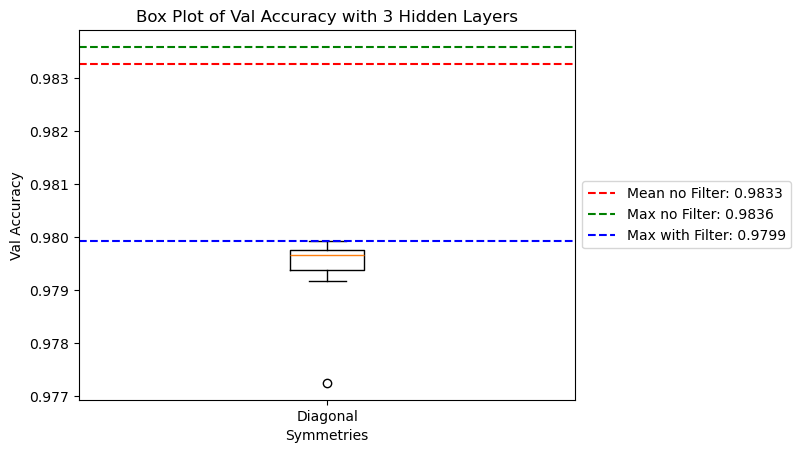

In [148]:
import matplotlib.pyplot as plt

# Combine the data into a list of lists
data = [diagonal_val_accuracy_flattened]

# Define the labels for the box plot
labels_plot = ['Diagonal']

# Create the box plot
plt.boxplot(data, labels=labels_plot)

# Calculate the mean value of the no_filter list
mean_no_filter = np.mean(no_fitler_val_accuracy)
max_no_filter = np.max(no_fitler_val_accuracy)

# Add a horizontal line at the mean value of no_filter
plt.axhline(y= mean_no_filter, color='r', linestyle='--', label=f'Mean no Filter: {mean_no_filter:.4f}')
plt.axhline(y= max_no_filter, color='g', linestyle='--', label=f'Max no Filter: {max_no_filter:.4f}')

# plt.ylim(0.936,.97)
max_val_accuracy = np.max([diagonal_val_accuracy_flattened])
plt.axhline(y= max_val_accuracy, color='b', linestyle='--', label=f'Max with Filter: {max_val_accuracy:.4f}')

# Add title and labels
number_of_hidden_layers = str(int(run_subfolder[1])-1)
plt.title(f'Box Plot of Val Accuracy with {number_of_hidden_layers} Hidden Layers')
plt.xlabel('Symmetries')
plt.ylabel('Val Accuracy')
# plt.legend(ncol=2, shadow=True)
# plt.legend(shadow=True)
# plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# Save the figure with high quality
data_name = "_Mnist"
figure_name = f"{log_dir}/{data_name}_{run_subfolder}_Val_Accuracy"
# plt.savefig(figure_name, dpi=300, bbox_inches='tight')
# Show the plot
plt.show()
